In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset using Pandas

In [4]:
df = pd.read_csv("Marketing.csv")

df.head()

,id,campaign_date,campaign_name,category,campaign_id,impressions,marketing_spent,clicks,leads,orders,revenue,ROI(%)
0,1,01-02-2021,facebook_tier1,social,349043,148263,7307.37,1210,13,1,4981,-31.835941
1,2,01-02-2021,facebOOK_tier2,social,348934,220688,16300.20,1640,48,3,14962,-8.209715
2,3,01-02-2021,google_hot,search,89459845,22850,5221.60,457,9,1,7981,52.845871
3,4,01-02-2021,google_wide,search,127823,147038,6037.00,1196,24,1,2114,-64.982607
4,5,01-02-2021,youtube_blogger,influencer,10934,225800,29962.20,2258,49,10,84490,181.988639


# Check missing values

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               308 non-null    int64  
 1   campaign_date    308 non-null    str    
 2   campaign_name    308 non-null    str    
 3   category         308 non-null    str    
 4   campaign_id      308 non-null    int64  
 5   impressions      308 non-null    int64  
 6   marketing_spent  308 non-null    float64
 7   clicks           308 non-null    int64  
 8   leads            308 non-null    int64  
 9   orders           308 non-null    int64  
 10  revenue          308 non-null    int64  
 11  ROI(%)           308 non-null    float64
dtypes: float64(2), int64(7), str(3)
memory usage: 29.0 KB


In [6]:
print(df.isnull().sum())

id                 0
campaign_date      0
campaign_name      0
category           0
campaign_id        0
impressions        0
marketing_spent    0
clicks             0
leads              0
orders             0
revenue            0
ROI(%)             0
dtype: int64


# Perform statistical analysis

In [7]:
print(df.describe())

               id   campaign_id   impressions  marketing_spent        clicks  \
count  308.000000  3.080000e+02  3.080000e+02       308.000000    308.000000   
mean   154.500000  9.605628e+06  5.122475e+06     99321.038377   9739.996753   
std     89.056162  2.543040e+07  2.631134e+07    144008.011181  12157.476244   
min      1.000000  1.093400e+04  6.670000e+02       169.750000     20.000000   
25%     77.750000  1.278230e+05  1.479568e+05      9465.195000   1347.250000   
50%    154.500000  3.747540e+05  6.028100e+05     36765.150000   4349.500000   
75%    231.250000  4.387490e+06  3.254450e+06    129372.250000  13499.250000   
max    308.000000  8.945984e+07  4.199700e+08    880357.000000  61195.000000   

             leads      orders       revenue      ROI(%)  
count   308.000000  308.000000  3.080000e+02  308.000000  
mean    212.918831   26.113636  1.392512e+05   40.761155  
std     300.459978   42.741288  2.763031e+05  121.770553  
min       0.000000    0.000000  0.000000e+0

In [8]:
df["campaign_date"] = pd.to_datetime(df["campaign_date"],format="%d-%m-%Y")

In [9]:
df["campaign_date"]

0     2021-02-01
1     2021-02-01
2     2021-02-01
3     2021-02-01
4     2021-02-01
         ...    
303   2021-02-28
304   2021-02-28
305   2021-02-28
306   2021-02-28
307   2021-02-28
Name: campaign_date, Length: 308, dtype: datetime64[us]

# Campaign vs Average ROI (Bar Chart)

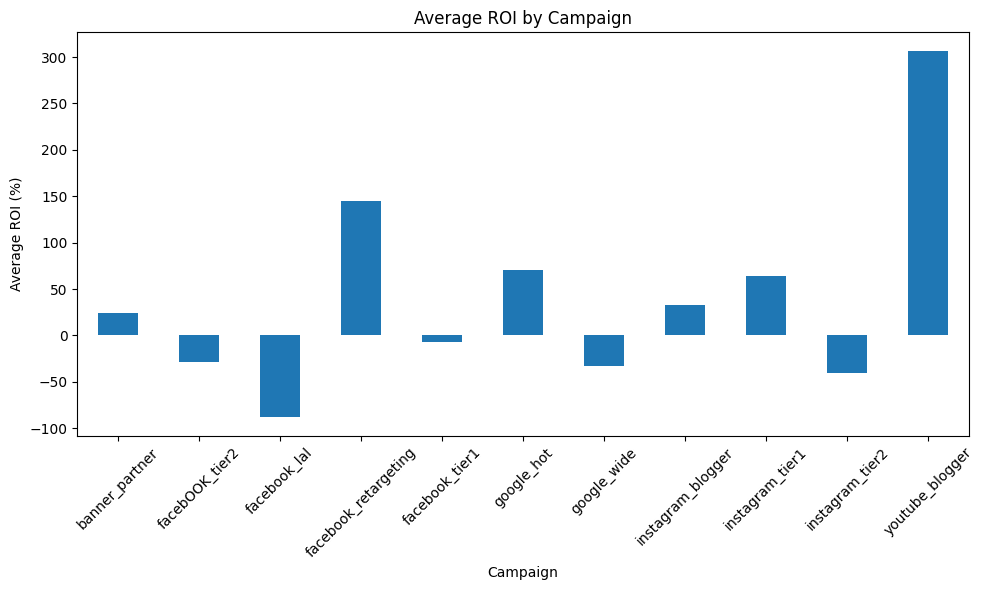

In [10]:
campaign_roi = df.groupby("campaign_name")["ROI(%)"].mean()

plt.figure(figsize=(10,6))
campaign_roi.plot(kind="bar")
plt.title("Average ROI by Campaign")
plt.xlabel("Campaign")
plt.ylabel("Average ROI (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Monthly Revenue Trend (Line Chart)

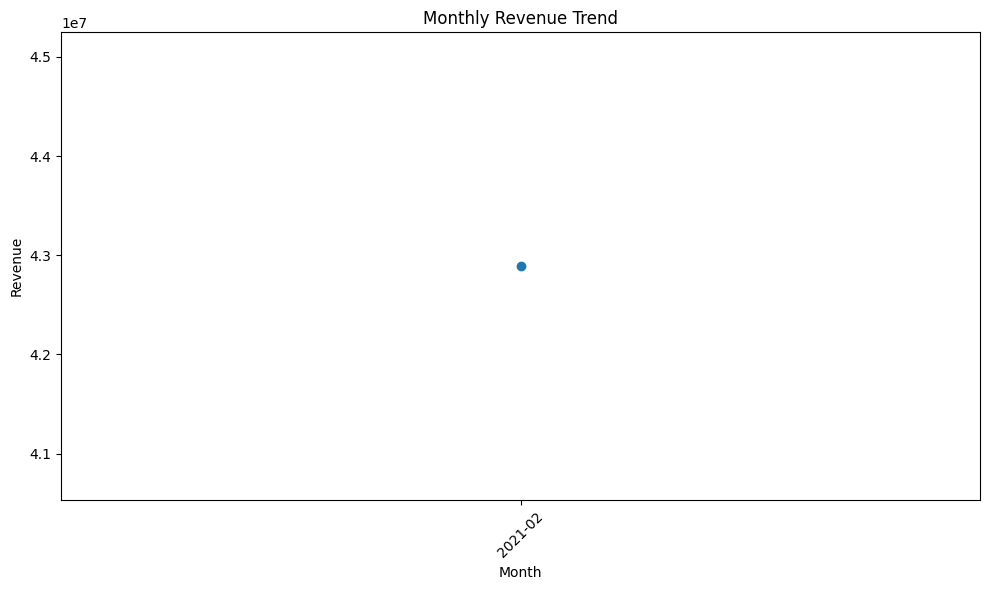

In [11]:
monthly_revenue = df.groupby(df["campaign_date"].dt.to_period("M"))["revenue"].sum()

monthly_revenue.index = monthly_revenue.index.astype(str)

plt.figure(figsize=(10,6))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Correlation Heatmap

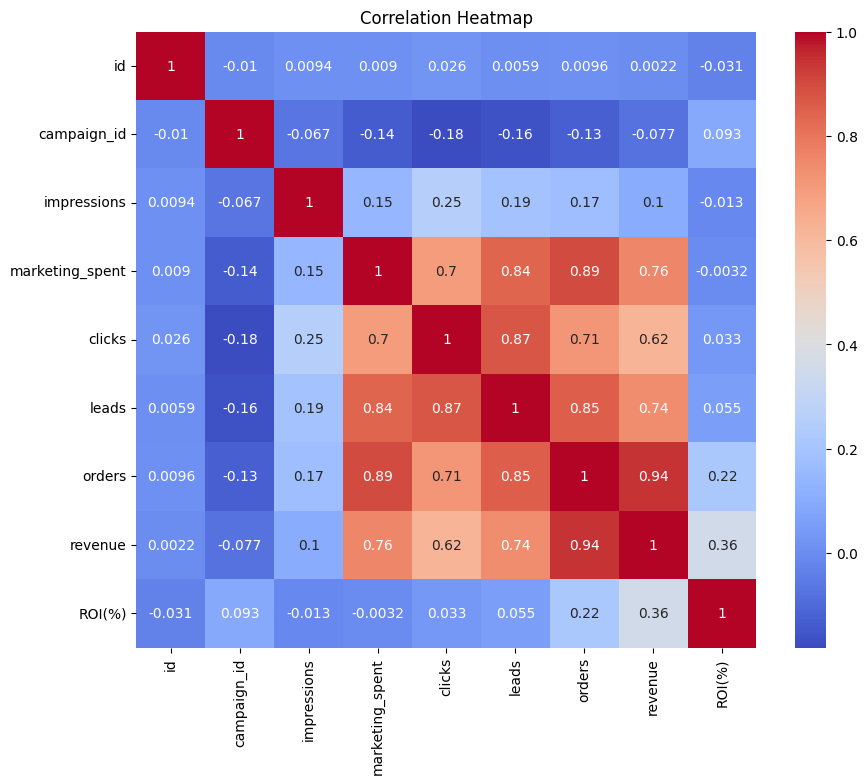

In [12]:
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Machine Learning Predict Revenue

In [13]:
X = df[
    [
        "marketing_spent",
        "impressions",
        "clicks",
        "leads",
        "orders"
    ]
]

y = df["revenue"]

# Split Dataset

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Model

In [15]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ -0.8 , -0. , 0.48,-122.05,9195.72]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['marketing_spent','impressions','clicks','leads','orders']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4858
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,5


# Make Predictions

In [16]:
predictions = model.predict(X_test)

print(predictions[:10])

[  3243.63588842  44904.66276605   7415.14774487  10079.32078672
  64305.64980769  15685.98683277 138555.91029829  42953.74760806
  18002.44594136 122195.40898818]


# Compare Actual vs Predicted

In [17]:
comparison = pd.DataFrame({
    "Actual Revenue": y_test,
    "Predicted Revenue": predictions
})

print(comparison.head(10))

     Actual Revenue  Predicted Revenue
288               0        3243.635888
9             39081       44904.662766
57             8136        7415.147745
60             5958       10079.320787
25            38753       64305.649808
63             6428       15685.986833
92           143658      138555.910298
184           31392       42953.747608
244           15050       18002.445941
46           177882      122195.408988


# Evaluate Model

In [18]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = mse ** 0.5
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Mean Absolute Error: 40316.636302585386
Mean Squared Error: 6681034987.824457
Root Mean Squared Error: 81737.59837323615
R2 Score: 0.8503410775952303
